# RoBERTa Benchmark - Symptoms Disease Classification

In [69]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding, pipeline
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

device = "cuda" if torch.cuda.is_available() else "cpu"

## Load Dataset

In [70]:
ds = load_dataset("ninaa510/diagnosis-text")

train_ds = ds["train"].rename_column("sentence1", "text").class_encode_column("label")
test_ds = ds["test"].rename_column("sentence1", "text").class_encode_column("label")

train_ds

Dataset({
    features: ['label', 'text'],
    num_rows: 13310
})

In [ ]:
train_ds[0]

{'label': 0,
 'text': 'I am a 12-year-old male with an itchy nose, sharp upper abdominal pain, pink skin lesions or rashes on my neck, swelling in my nose, had an allergic reaction, and experiencing high-pitched breathing sounds, lightheadedness, and wheezing on exhale.'}

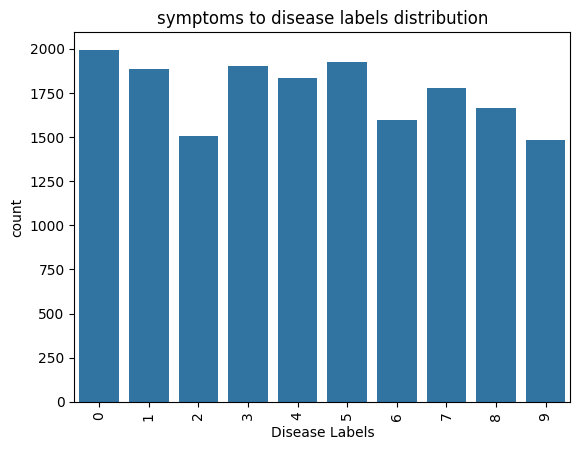

In [73]:
train = pd.DataFrame(ds["train"])
test = pd.DataFrame(ds["test"])

df = pd.concat([train, test], ignore_index=True)

sns.countplot(data=df, x="label")
plt.title("symptoms to disease labels distribution")
plt.xlabel("Disease Labels")
plt.xticks(rotation=90)
plt.ylabel("count")
plt.show()

In [74]:
total_labels = len(set(train_ds["label"]))
print(f"Total number of labels: {total_labels}")

Total number of labels: 10


## Load RoBERTa Model

In [75]:
roberta = "roberta-base"

roberta_tokenizer = AutoTokenizer.from_pretrained(roberta)

roberta_model = AutoModelForSequenceClassification.from_pretrained(
    roberta,
    num_labels=total_labels,
)

roberta_model.to(device)

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 1635.15it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consid

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

In [76]:
# Total number of parameters
roberta_params = sum(p.numel() for p in roberta_model.parameters() if p.requires_grad)
print(f"RoBERTa parameters: {roberta_params:,}")

RoBERTa parameters: 124,653,322


## Tokenizing Dataset

In [77]:
def tokenize(batch):
    return roberta_tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=256
    )

tokenized_train = train_ds.map(tokenize, batched=True, batch_size=1024)
tokenized_test = test_ds.map(tokenize, batched=True, batch_size=1024)

Map: 100%|██████████| 4262/4262 [00:00<00:00, 19464.40 examples/s]


In [78]:
tokenized_train, tokenized_test

(Dataset({
     features: ['label', 'text', 'input_ids', 'attention_mask'],
     num_rows: 13310
 }),
 Dataset({
     features: ['label', 'text', 'input_ids', 'attention_mask'],
     num_rows: 4262
 }))

In [79]:
# remove the raw text column, we dont want a string
tokenized_train = tokenized_train.remove_columns(["text"])
tokenized_test = tokenized_test.remove_columns(["text"])

tokenized_train.set_format("torch")
tokenized_test.set_format("torch")

In [80]:
tokenized_train

Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 13310
})

## Model Training (Fine Tuning)

In [81]:
def compute_metrics(pred):
    logits, labels = pred
    preds = logits.argmax(axis=-1)

    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="weighted")

    return {"accuracy": acc, "f1": f1}

In [82]:
LR = 2e-5
BATCH_SIZE = 16
NUM_EPOCH = 3

output_path = "./results/roberta"

training_args = TrainingArguments(
    output_dir=output_path,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=LR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=NUM_EPOCH,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
)

In [83]:
data_collator = DataCollatorWithPadding(roberta_tokenizer)

In [84]:
trainer = Trainer(
    model=roberta_model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [85]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.636311,0.996256,0.599015,0.569576
2,0.972380,0.966205,0.580244,0.570066
3,0.952133,0.955177,0.585875,0.568106


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.84it/s]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.la

TrainOutput(global_step=2496, training_loss=1.1053101833050067, metrics={'train_runtime': 634.0372, 'train_samples_per_second': 62.977, 'train_steps_per_second': 3.937, 'total_flos': 5253389537679360.0, 'train_loss': 1.1053101833050067, 'epoch': 3.0})

In [86]:
trainer.save_model(output_path)
roberta_tokenizer.save_pretrained(output_path)

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.36it/s]


('./results/roberta\\tokenizer_config.json',
 './results/roberta\\tokenizer.json')

## Model Evaluation

In [87]:
eval_results = trainer.evaluate(eval_dataset=tokenized_test)
eval_results

{'eval_loss': 0.9959812164306641,
 'eval_accuracy': 0.5997184420459878,
 'eval_f1': 0.5702198120052425,
 'eval_runtime': 20.4835,
 'eval_samples_per_second': 208.07,
 'eval_steps_per_second': 13.035,
 'epoch': 3.0}

In [88]:
pred = trainer.predict(test_dataset=tokenized_test)
pred.predictions, pred.label_ids

(array([[-1.7594929 ,  1.235722  , -0.342243  , ..., -1.1153994 ,
         -1.9040681 , -2.1226406 ],
        [-1.206423  ,  2.8371515 , -0.4698794 , ..., -0.3739866 ,
         -1.8825037 , -1.2737329 ],
        [ 4.744268  , -0.42028844, -1.1928475 , ..., -0.05859982,
         -1.5188136 , -0.1272284 ],
        ...,
        [ 5.059188  , -1.0169779 , -1.5040511 , ..., -1.0284569 ,
         -0.8242507 , -0.7274181 ],
        [ 0.8867743 , -1.8013824 , -1.3778265 , ..., -0.7670521 ,
         -0.4303418 , -1.5929791 ],
        [-1.4421932 ,  5.0986066 , -0.10906366, ...,  0.7429156 ,
         -1.1053675 , -0.94431144]], shape=(4262, 10), dtype=float32),
 array([6, 5, 0, ..., 4, 4, 1], shape=(4262,)))

In [89]:
pred_labels = np.argmax(pred.predictions, axis=1)
pred_labels

array([6, 5, 0, ..., 0, 4, 1], shape=(4262,))

In [90]:
y_df = pd.DataFrame({
    "predicted": pred_labels,
    "true": pred.label_ids,
})
y_df.head()

,predicted,true
0,6,6
1,5,5
2,0,0
3,4,4
4,5,1


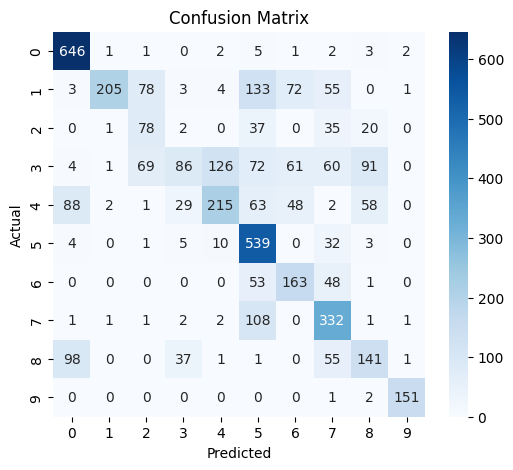

In [91]:
cm = confusion_matrix(pred.label_ids, pred_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [92]:
report = classification_report(pred.label_ids, pred_labels, output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_report.head(9 + 4)

,precision,recall,f1-score,support
0,0.765403,0.974359,0.857332,663.000000
1,0.971564,0.370036,0.535948,554.000000
2,0.340611,0.450867,0.388060,173.000000
3,0.524390,0.150877,0.234332,570.000000
4,0.597222,0.424901,0.496536,506.000000
5,0.533136,0.907407,0.671651,594.000000
6,0.472464,0.615094,0.534426,265.000000
7,0.533762,0.739421,0.619981,449.000000
8,0.440625,0.422156,0.431193,334.000000
9,0.967949,0.980519,0.974194,154.000000


# Inference Example

In [93]:
output_path = "./results/roberta"

tokenizer = AutoTokenizer.from_pretrained(output_path)
model = AutoModelForSequenceClassification.from_pretrained(output_path)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1513.06it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              


In [94]:
model.config.id2label = dict(enumerate(train_ds.features["label"].names))
model.config.label2id = {v:k for k,v in model.config.id2label.items()}

In [95]:
classifier = pipeline("text-classification", model=model, tokenizer=tokenizer)

classifier("i have itchy nose, and i dont feel well")

[{'label': 'Allergic sinusitis', 'score': 0.9471334218978882}]